In [11]:
!pip install -U polars pandas matplotlib seaborn wordcloud transformers torch tqdm scikit-learn Pillow rapidfuzz nltk -q

In [12]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from transformers import pipeline
from tqdm.auto import tqdm
import torch
import warnings
from rapidfuzz import fuzz
import nltk
import os
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')
tqdm.pandas()

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [3]:
df = pl.read_parquet("anka_ajansi_haberler.parquet")
total_rows = df.height
chunk_size = 20000
prefix_clean_regex = r"^\s*(?:Haber\s*:\s*[^/(\n]+?\s*)?(?:/\s*Kamera\s*:\s*[^(\n]+?\s*)?(?:Kamera\s*:\s*[^(\n]+?\s*)?(?:\(\s*[A-ZĞÜŞİÖÇIı\s\-\_]{2,}\s*\)|[A-ZĞÜŞİÖÇa-zğüşiöçIı\s]{2,30}?\s*\(\s*[A-ZĞÜŞİÖÇIı\s\-\_]{2,}\s*\))\s*(?:-|–)?\s*"
ozet_prefix_regex = r"^\s*(?:[A-ZĞÜŞİÖÇa-zğüşiöçIı\s]{2,15}?)\s*,\s*(?:[A-ZĞÜŞİÖÇIı\s\-\_]{2,})\s{2,}"
video_regex = r"Video'yu\s+İndir\s*\(\d+p\)|Video'yu\s+İndir"
suffix_regex = r"\s*\(\s*(?:SÜRECEK|SON|BİTTİ|ARŞİV|ANKA|TSİ|ARŞİV GÖRÜNTÜ|ADVERTORIAL YAYIN|GÖRÜNTÜ EKLENECEK|GÖRÜNTÜLÜ - CANLI / İSTANBUL|ARŞİV FOTOĞRAF|GÖRÜNTÜLÜ - CANLI / İZMİR|GÖRÜNTÜLÜ/ANKARA|GÖRÜNTÜLÜ - ANKARA)\s*\)\.?\s*$"
def clean_data(chunk):
    return chunk.select([
        pl.col("UUID"),
        pl.col("Tarih").str.split(" ~ ").list.get(0).str.to_datetime(format="%d.%m.%Y %H:%M", strict=False).alias("Yayin_Tarihi"),
        pl.col("Tarih").str.split(" ~ ").list.get(-1).str.to_datetime(format="%d.%m.%Y %H:%M", strict=False).alias("Guncelleme_Tarihi"),
        pl.col("Baslik").str.strip_chars().alias("Baslik"),
        pl.col("Kategori").str.strip_chars().alias("Kategori"),
        pl.col("Sehir").str.strip_chars().alias("Sehir_Kayit"),
        pl.when(pl.col("Detay_Metin").str.contains(r"^\s*Haber\s*:")).then(pl.col("Detay_Metin").str.extract(r"^\s*Haber\s*:\s*([^/(\n]+?)\s*(?:/|\()", 1)).otherwise(pl.col("Detay_Metin").str.extract(r"^\s*([A-ZĞÜŞİÖÇa-zğüşiöçIı]{2,15}(?:\s+[A-ZĞÜŞİÖÇa-zğüşiöçIı]{2,15}){1,3})\s*\(\s*[A-ZĞÜŞİÖÇIı\s\-\_]{2,}\s*\)", 1)).str.strip_chars().alias("Muhabir"),
        pl.col("Detay_Metin").str.extract(r"Kamera\s*:\s*([^(\n]+?)\s*\(", 1).str.strip_chars().alias("Kameraman"),
        pl.col("Detay_Metin").str.extract(r"\(\s*([A-ZĞÜŞİÖÇIı\s\-\_]{2,})\s*\)", 1).str.strip_chars().alias("Haber_Sehri"),
        pl.col("Detay_Metin").str.replace(prefix_clean_regex, "").str.replace(suffix_regex, "").str.replace_all(r"\s+", " ").str.strip_chars().alias("Detay_Metin_Temiz"),
        pl.col("Ozet").str.replace(ozet_prefix_regex, "").str.replace_all(video_regex, "").str.replace(suffix_regex, "").str.replace_all(r"\s+", " ").str.strip_chars().alias("Ozet_Temiz"),
        pl.col("Resimler").str.split(" | ").alias("Resim_Listesi"),
        pl.col("Resimler").str.split(" | ").list.len().fill_null(0).alias("Resim_Sayisi"),
        pl.col("Detay_Metin").str.replace(prefix_clean_regex, "").str.replace(suffix_regex, "").str.replace_all(r"\s+", " ").str.strip_chars().str.extract_all(r"\b[A-ZĞÜŞİÖÇ]{2,6}\b").list.unique().alias("Kısaltmalar")
    ])
chunks = []
for offset in tqdm(range(0, total_rows, chunk_size)):
    chunk = df.slice(offset, chunk_size)
    chunks.append(clean_data(chunk))
df_cleaned = pl.concat(chunks)
df_pd = df_cleaned.to_pandas()
df_pd['Yil'] = df_pd['Yayin_Tarihi'].dt.year
df_pd['Kategori'] = df_pd['Kategori'].replace('AnkaHaber Gündem', 'Gündem')

100%|██████████| 14/14 [00:19<00:00,  1.38s/it]


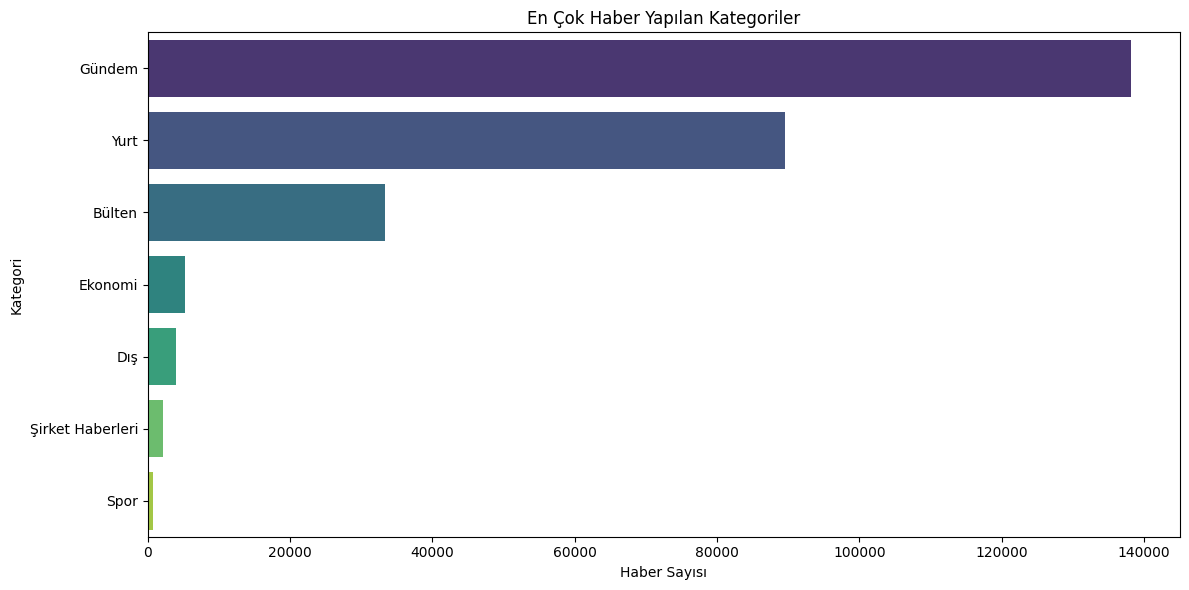

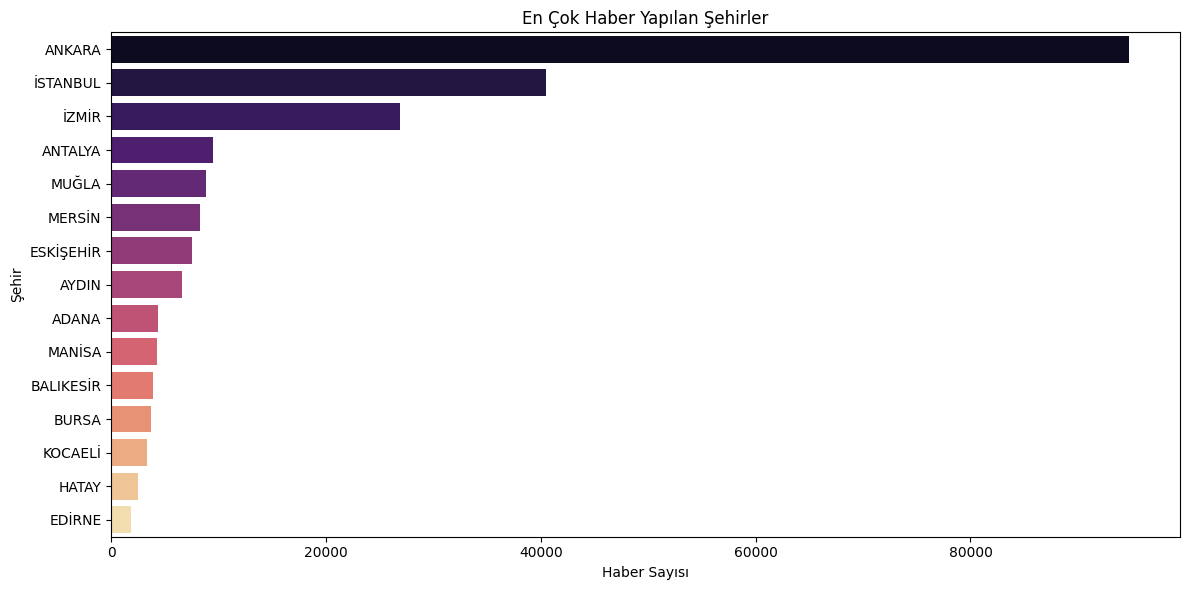

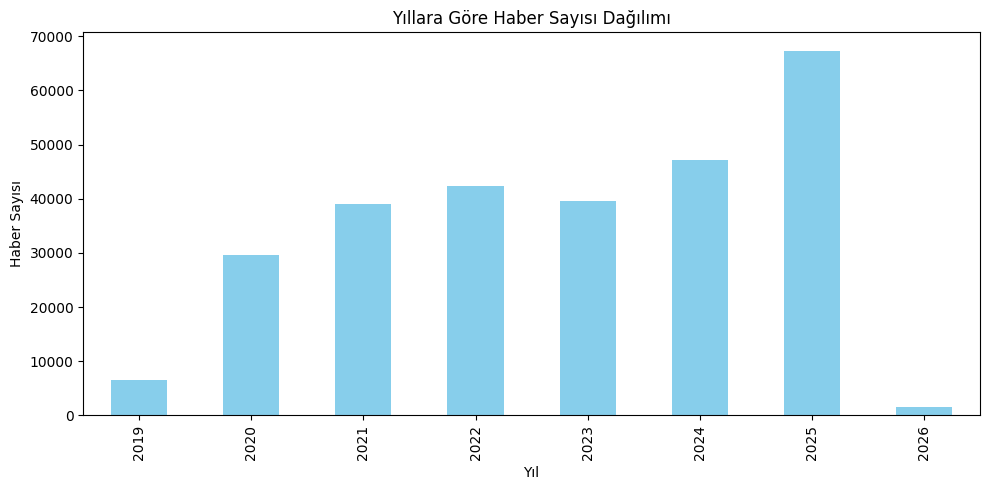

In [4]:
plt.figure(figsize=(12, 6))
sns.countplot(y='Kategori', data=df_pd, order=df_pd['Kategori'].value_counts().index[:15], palette='viridis')
plt.title('En Çok Haber Yapılan Kategoriler')
plt.xlabel('Haber Sayısı')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 6))
sns.countplot(y='Sehir_Kayit', data=df_pd, order=df_pd['Sehir_Kayit'].value_counts().index[:15], palette='magma')
plt.title('En Çok Haber Yapılan Şehirler')
plt.xlabel('Haber Sayısı')
plt.ylabel('Şehir')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
df_pd.groupby('Yil').size().plot(kind='bar', color='skyblue')
plt.title('Yıllara Göre Haber Sayısı Dağılımı')
plt.xlabel('Yıl')
plt.ylabel('Haber Sayısı')
plt.tight_layout()
plt.show()

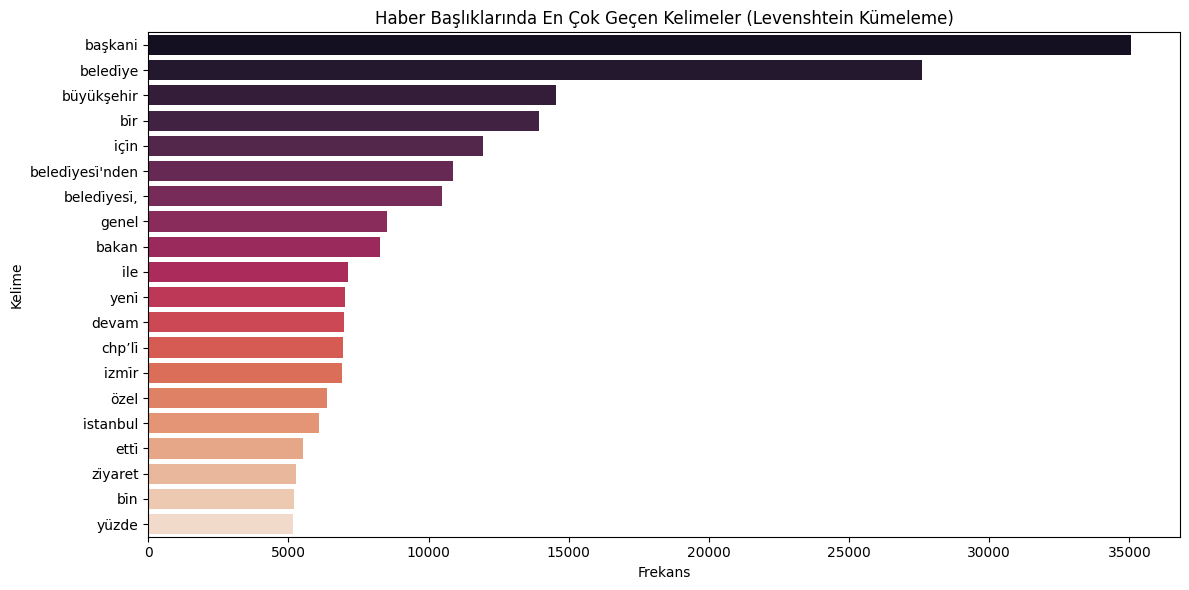

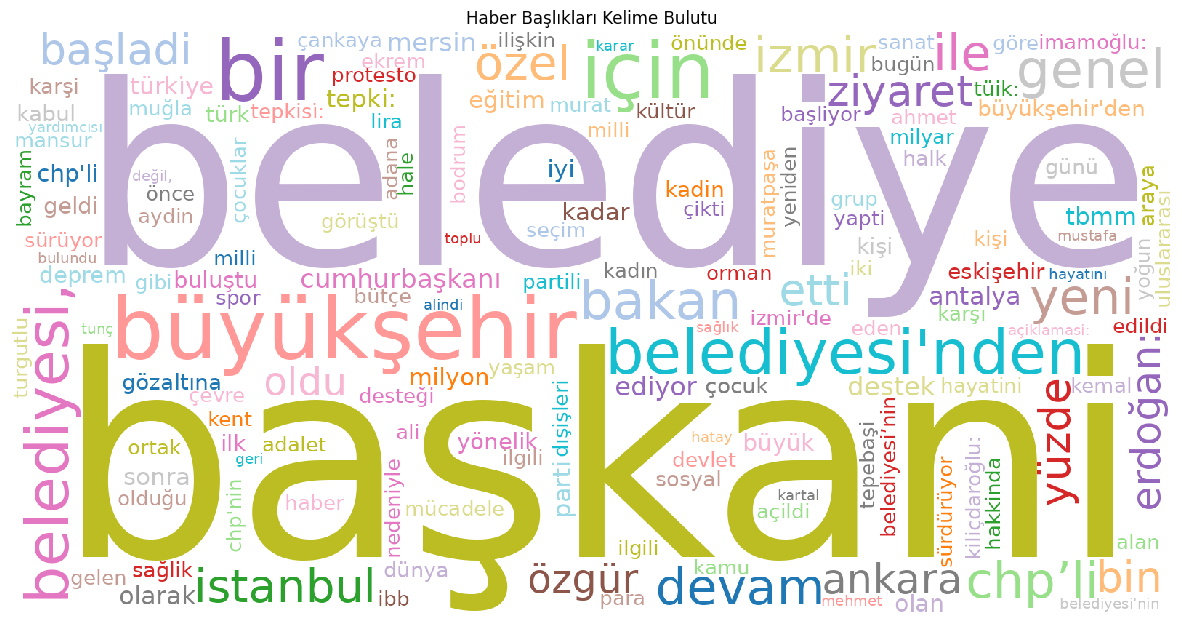

In [5]:
tr_stops = set(stopwords.words('turkish'))
text_data = " ".join(df_pd['Baslik'].dropna().tolist())
all_words = [w for w in text_data.lower().split() if len(w) > 3 and w not in tr_stops]
raw_counts = Counter(all_words).most_common(200)
final_counts = {}
for word, count in raw_counts:
    found = False
    for key in final_counts.keys():
        if fuzz.ratio(word, key) > 85:
            final_counts[key] += count
            found = True
            break
    if not found:
        final_counts[word] = count
words_df = pd.DataFrame(Counter(final_counts).most_common(20), columns=['Kelime', 'Frekans'])
plt.figure(figsize=(12, 6))
sns.barplot(x='Frekans', y='Kelime', data=words_df, palette='rocket')
plt.title('Haber Başlıklarında En Çok Geçen Kelimeler (Levenshtein Kümeleme)')
plt.tight_layout()
plt.show()
clean_text_data = " ".join([w for w in all_words if w in final_counts or w not in dict(raw_counts)])
wordcloud = WordCloud(width=1600, height=800, font_path="/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", background_color='white', colormap='tab20', regexp=r"[a-zA-ZçÇğĞıİöÖşŞüÜ]+").generate_from_frequencies(final_counts)
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='nearest')
plt.axis('off')
plt.title('Haber Başlıkları Kelime Bulutu')
plt.show()

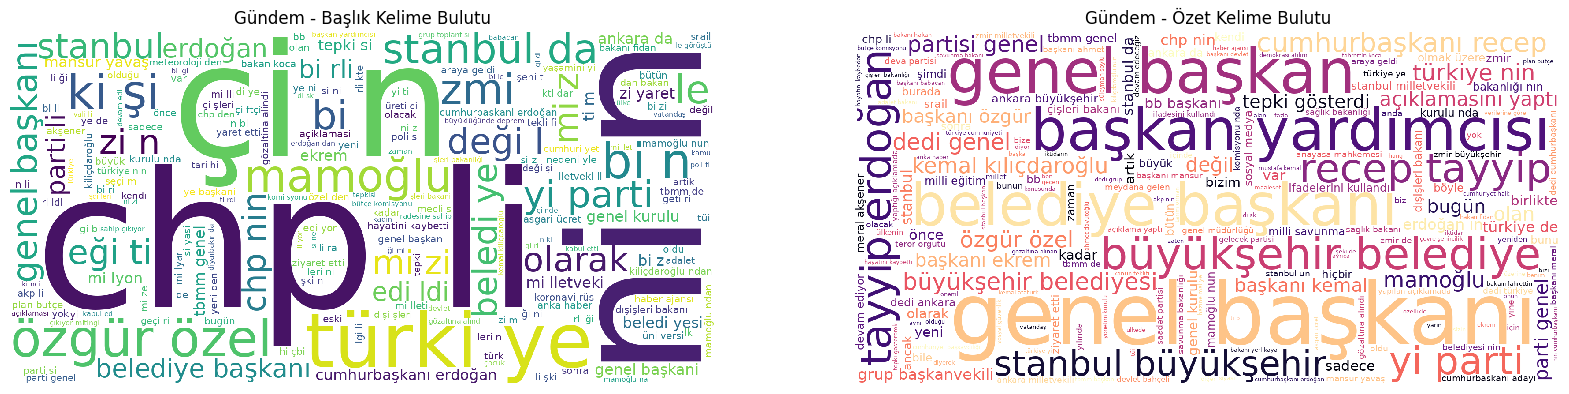

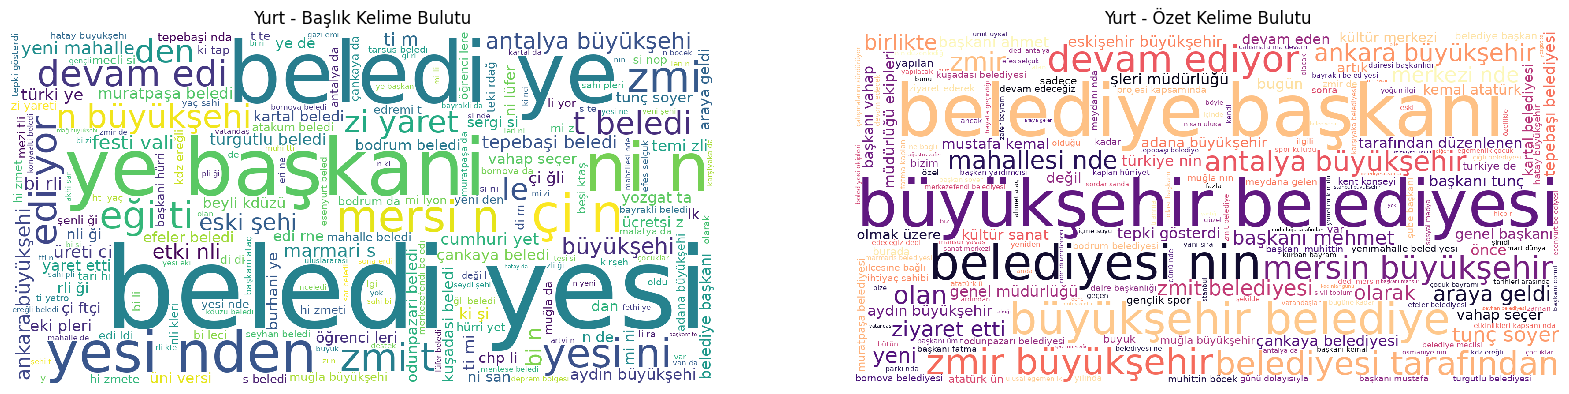

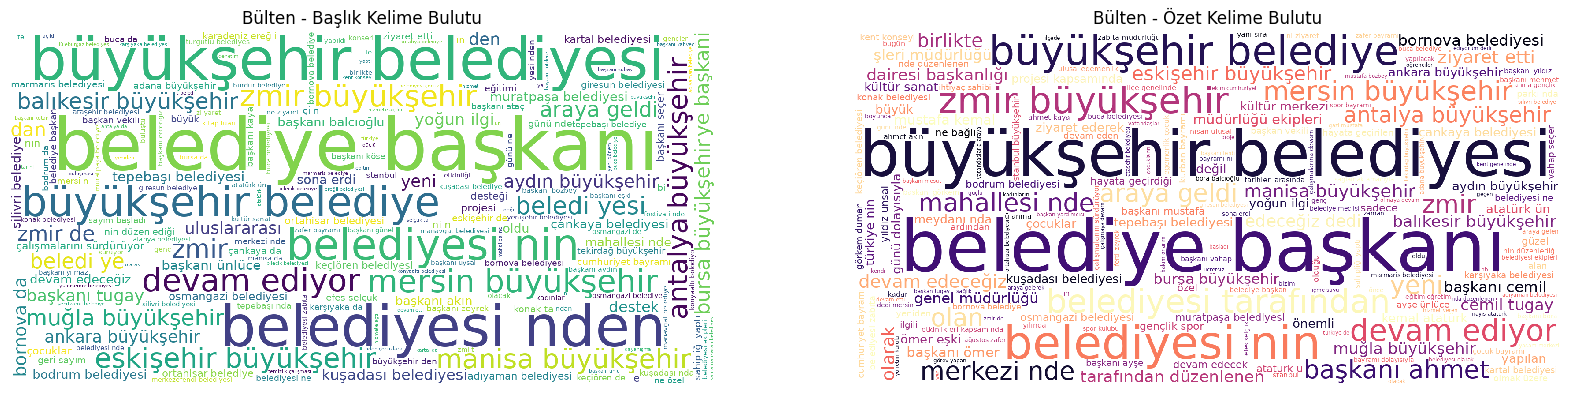

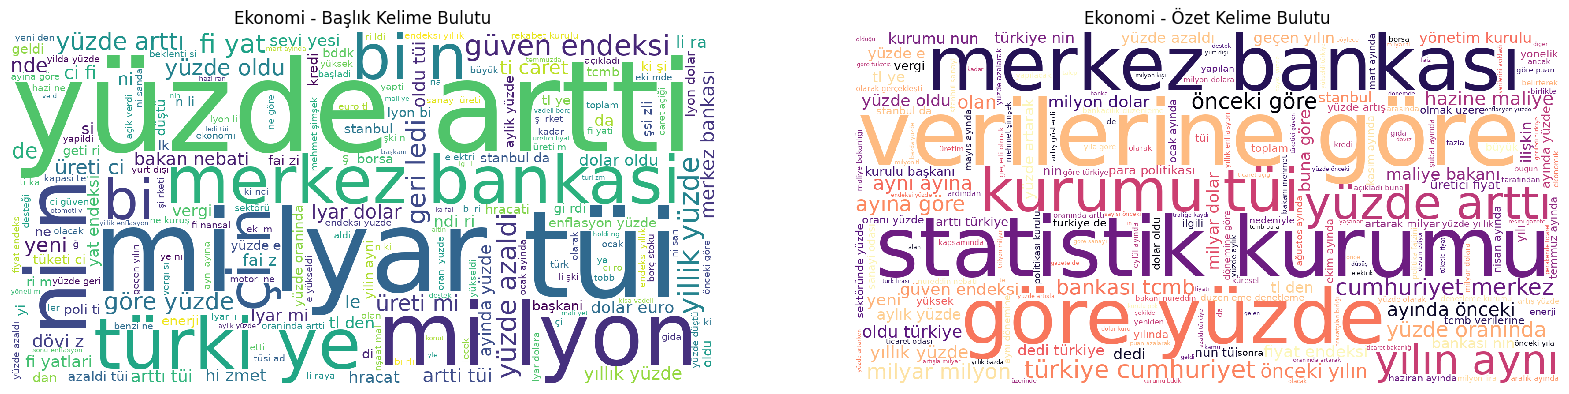

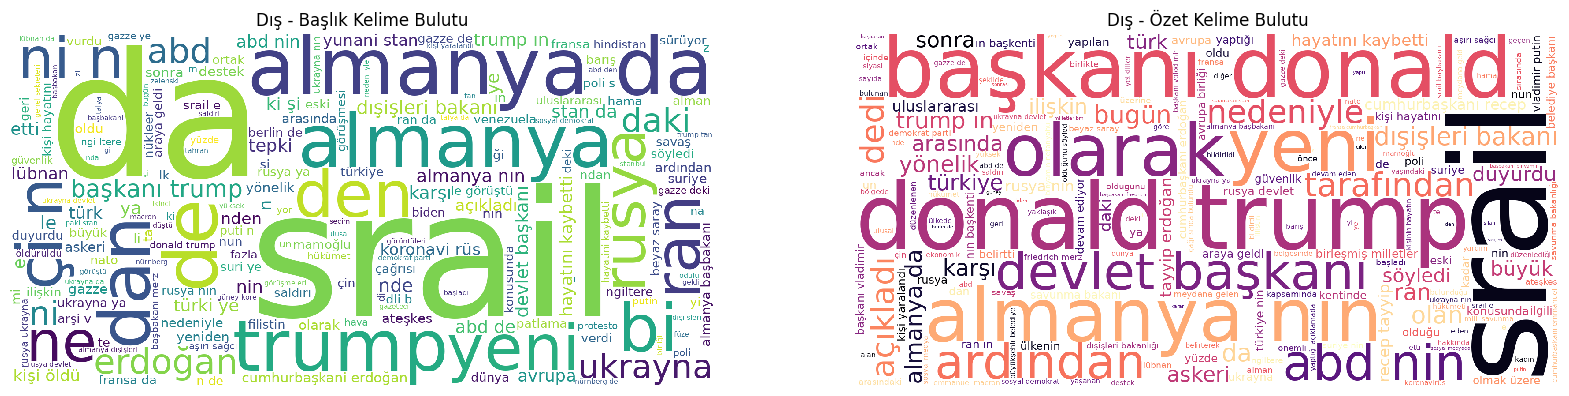

In [6]:
top_cats = df_pd['Kategori'].value_counts().index[:5]
for cat in top_cats:
    cat_df = df_pd[df_pd['Kategori'] == cat]
    cat_baslik = " ".join(cat_df['Baslik'].dropna().tolist())
    cat_ozet = " ".join(cat_df['Ozet_Temiz'].dropna().tolist())
    cat_baslik_clean = " ".join([w for w in cat_baslik.lower().split() if len(w)>3 and w not in tr_stops])
    cat_ozet_clean = " ".join([w for w in cat_ozet.lower().split() if len(w)>3 and w not in tr_stops])
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    if len(cat_baslik_clean) > 0:
        wc_baslik = WordCloud(width=1600, height=800, font_path="/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", background_color='white', colormap='viridis', regexp=r"[a-zA-ZçÇğĞıİöÖşŞüÜ]+").generate(cat_baslik_clean)
        axes[0].imshow(wc_baslik, interpolation='nearest')
    axes[0].axis('off')
    axes[0].set_title(f'{cat} - Başlık Kelime Bulutu')
    if len(cat_ozet_clean) > 0:
        wc_ozet = WordCloud(width=1600, height=800, font_path="/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", background_color='white', colormap='magma', regexp=r"[a-zA-ZçÇğĞıİöÖşŞüÜ]+").generate(cat_ozet_clean)
        axes[1].imshow(wc_ozet, interpolation='nearest')
    axes[1].axis('off')
    axes[1].set_title(f'{cat} - Özet Kelime Bulutu')
    plt.show()

In [7]:
device = 0 if torch.cuda.is_available() else -1
offensive_pipe = pipeline("text-classification", model="TURKCELL/bert-offensive-lang-detection-tr", device=device, model_kwargs={"torch_dtype": torch.float16})
emotion_pipe = pipeline("text-classification", model="kubi565/emotion-berturk-turkish", device=device, model_kwargs={"torch_dtype": torch.float16})
ner_pipe = pipeline("ner", model="savasy/bert-base-turkish-ner-cased", aggregation_strategy="simple", device=device, model_kwargs={"torch_dtype": torch.float16})
sentiment_pipe = pipeline("text-classification", model="savasy/bert-base-turkish-sentiment-cased", device=device, model_kwargs={"torch_dtype": torch.float16})

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6599.51it/s]
[transformers] BertForTokenClassification LOAD REPORT from: savasy/bert-base-turkish-ner-cased
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7409.98it/s]


In [8]:
texts = df_pd['Ozet_Temiz'].fillna("").tolist()
batch_size = 512
def data_gen(data_list):
    for item in data_list:
        yield item
offensive_results = []
for out in tqdm(offensive_pipe(data_gen(texts), batch_size=batch_size, truncation=True, max_length=128), total=len(texts)):
    offensive_results.append(out['label'])
emotion_results = []
for out in tqdm(emotion_pipe(data_gen(texts), batch_size=batch_size, truncation=True, max_length=128), total=len(texts)):
    emotion_results.append(out['label'])
sentiment_results = []
for out in tqdm(sentiment_pipe(data_gen(texts), batch_size=batch_size, truncation=True, max_length=128), total=len(texts)):
    sentiment_results.append(out['label'])
df_pd['Offensive'] = offensive_results
df_pd['Emotion'] = emotion_results
df_pd['Sentiment'] = sentiment_results


100%|██████████| 273046/273046 [07:52<00:00, 577.70it/s]


100%|██████████| 273046/273046 [00:00<00:00, 1079782.59it/s]


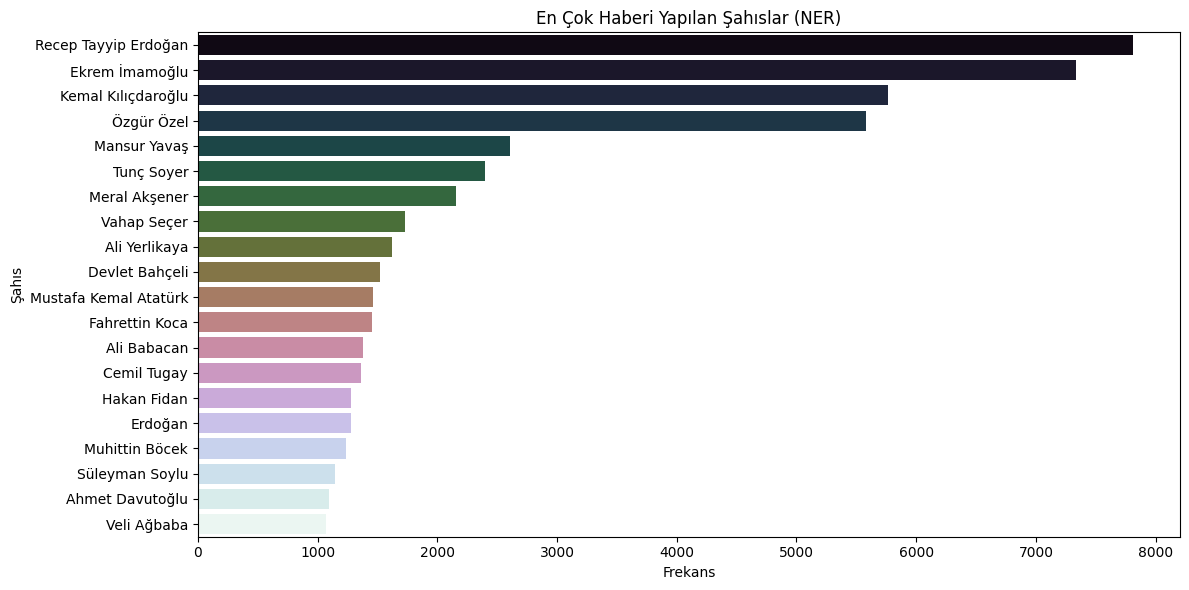

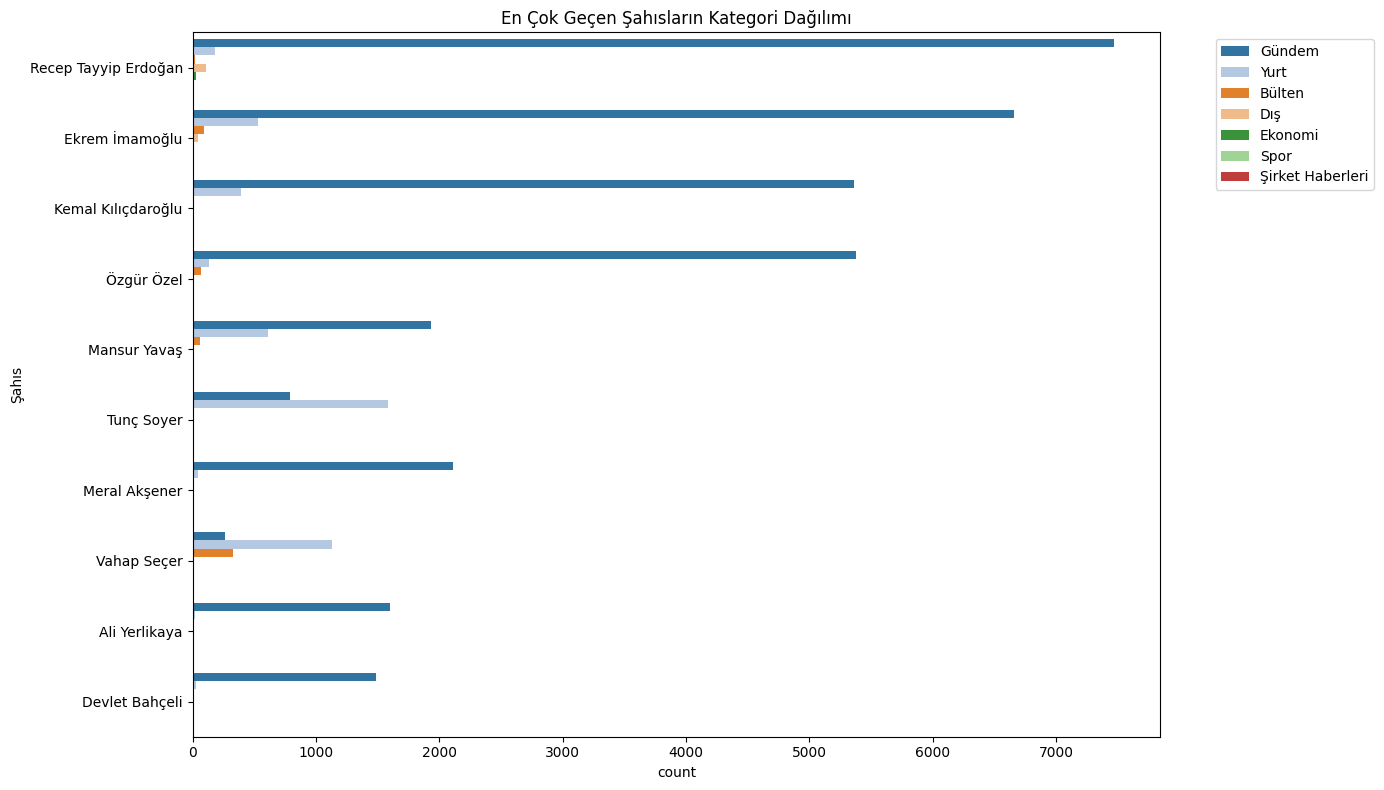

In [9]:
import torch
torch.cuda.empty_cache()
categories = df_pd['Kategori'].tolist()
all_persons = []
person_cats = []
for i, entities in enumerate(tqdm(ner_pipe(texts, batch_size=64), total=len(texts))):
    cat = categories[i]
    for ent in entities:
        if ent['entity_group'] == 'PER':
            all_persons.append(ent['word'])
            person_cats.append((ent['word'], cat))
person_counts = Counter(all_persons).most_common(20)
person_df = pd.DataFrame(person_counts, columns=['Şahıs', 'Frekans'])
plt.figure(figsize=(12, 6))
sns.barplot(x='Frekans', y='Şahıs', data=person_df, palette='cubehelix')
plt.title('En Çok Haberi Yapılan Şahıslar (NER)')
plt.tight_layout()
plt.show()
top_persons = [p[0] for p in person_counts[:10]]
cat_dist = pd.DataFrame(person_cats, columns=['Şahıs', 'Kategori'])
cat_dist = cat_dist[cat_dist['Şahıs'].isin(top_persons)]
plt.figure(figsize=(14, 8))
sns.countplot(data=cat_dist, y='Şahıs', hue='Kategori', order=top_persons, palette='tab20')
plt.title('En Çok Geçen Şahısların Kategori Dağılımı')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

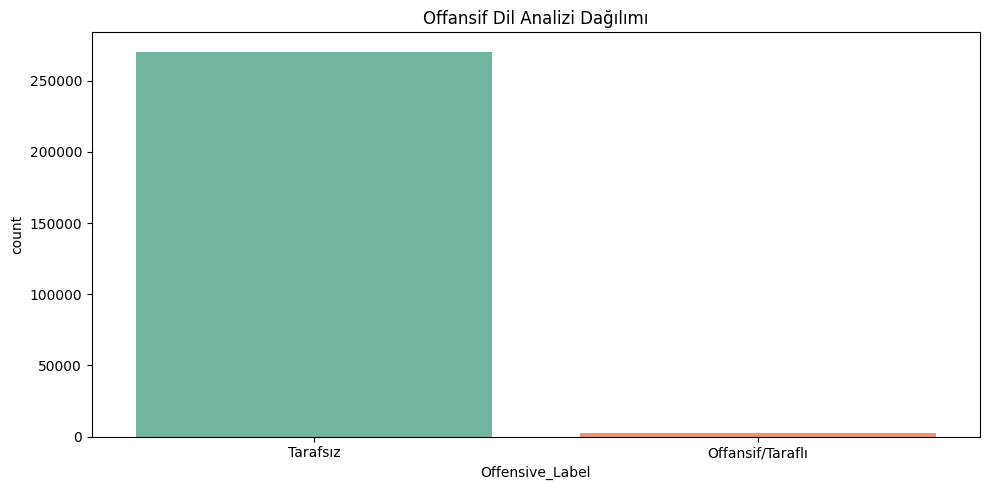

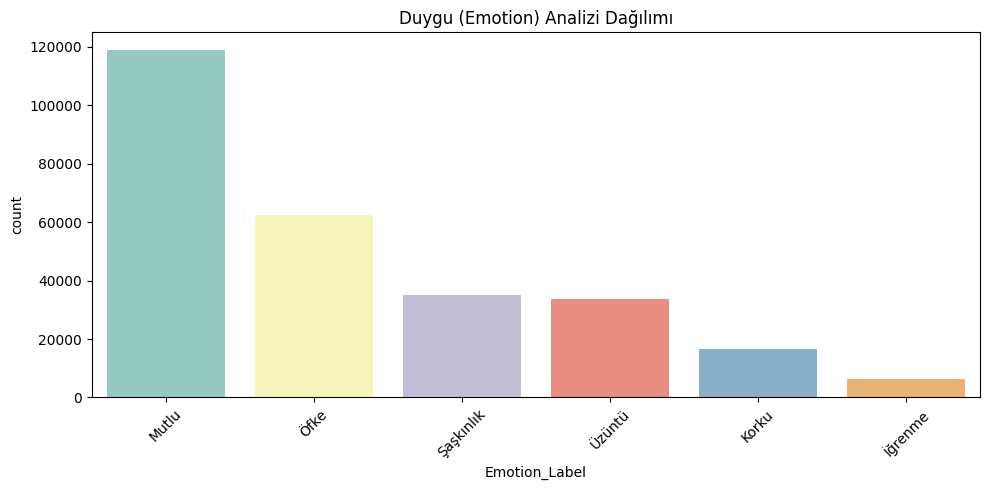

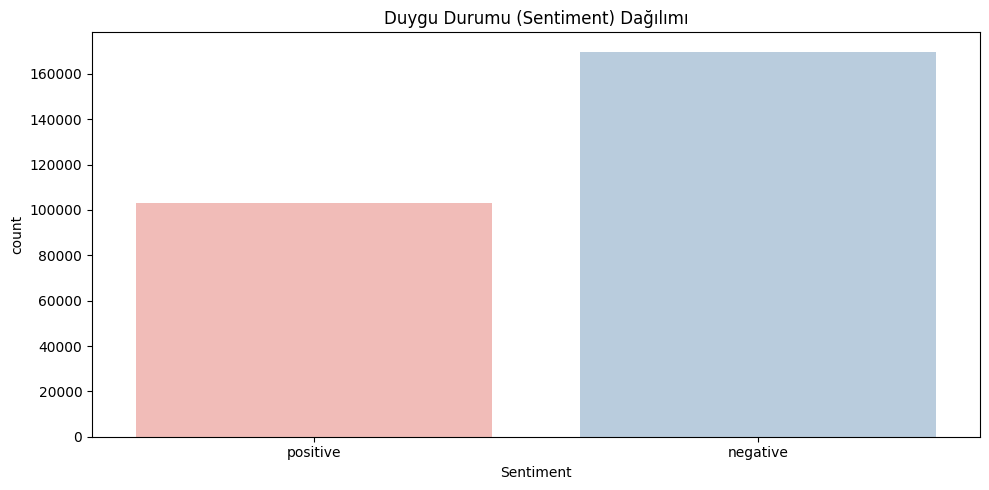

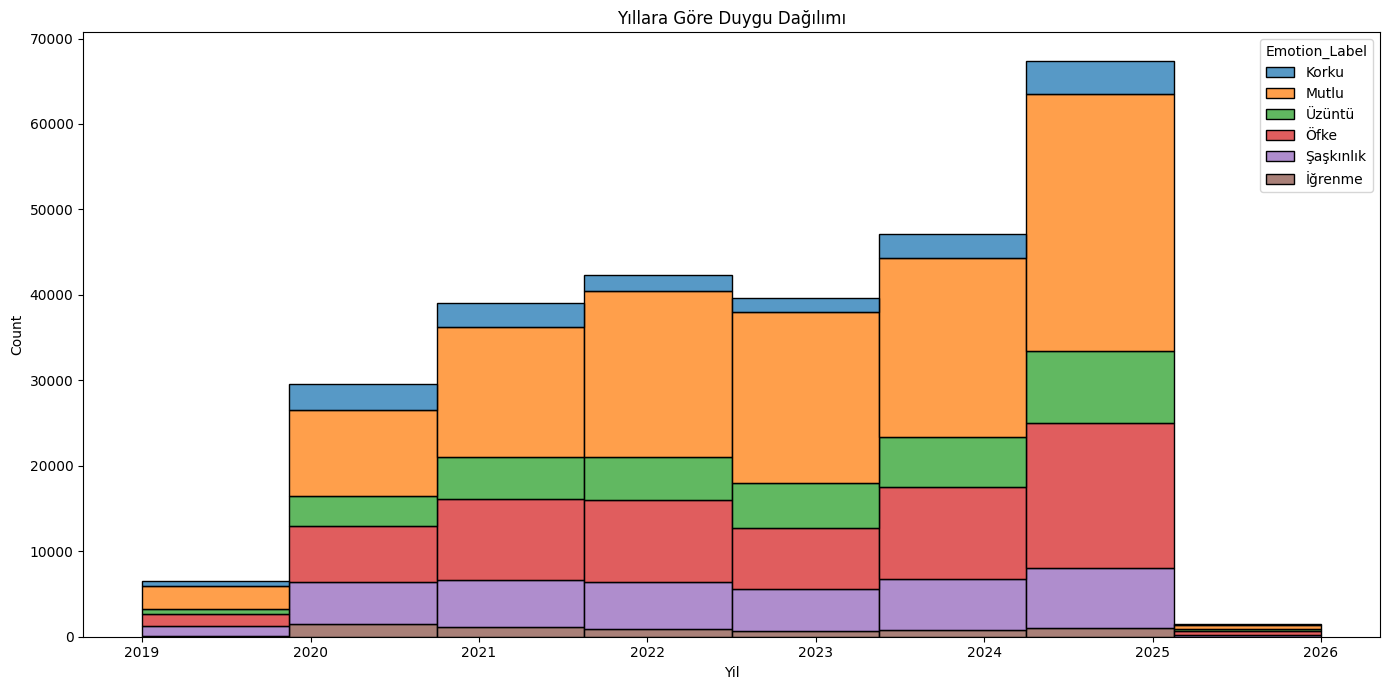

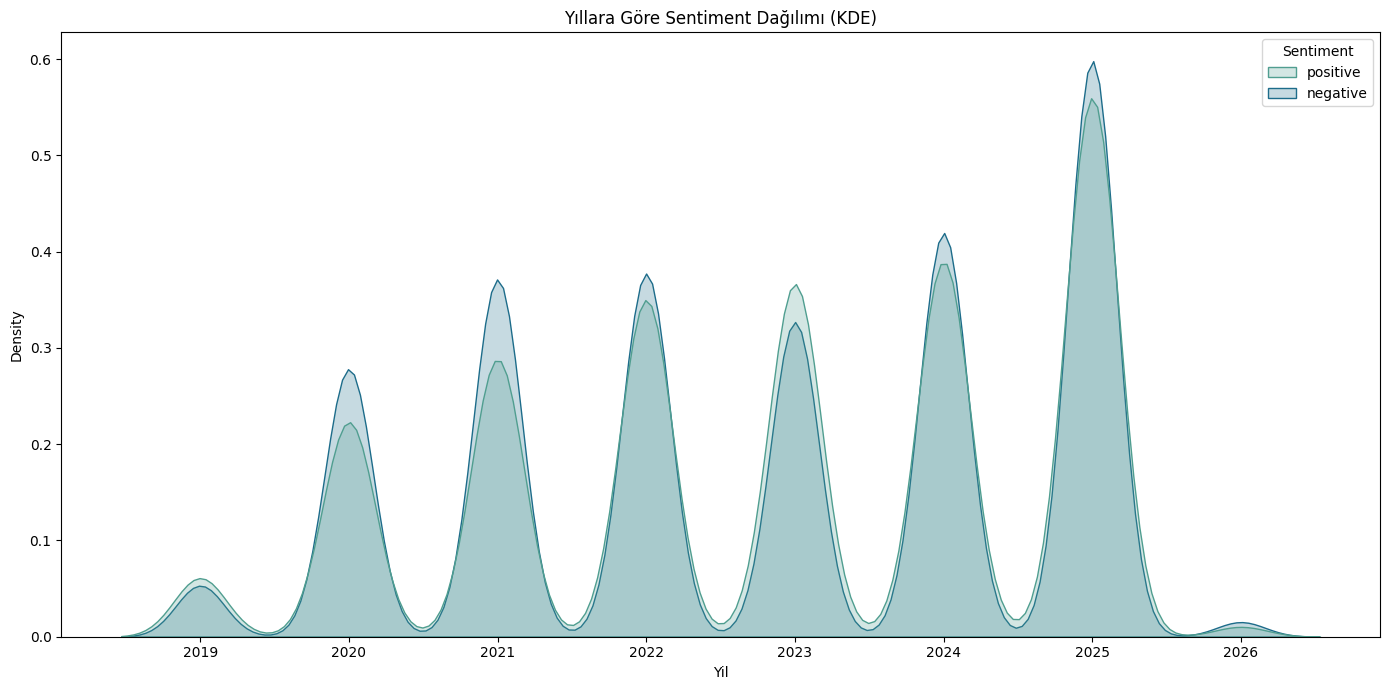

In [10]:
off_map = {'LABEL_0': 'Tarafsız', 'LABEL_1': 'Offansif/Taraflı'}
emo_map = {'LABEL_0': 'Mutlu', 'LABEL_1': 'Korku', 'LABEL_2': 'Öfke', 'LABEL_3': 'Üzüntü', 'LABEL_4': 'İğrenme', 'LABEL_5': 'Şaşkınlık'}
df_pd['Offensive_Label'] = df_pd['Offensive'].map(off_map).fillna(df_pd['Offensive'])
df_pd['Emotion_Label'] = df_pd['Emotion'].map(emo_map).fillna(df_pd['Emotion'])
plt.figure(figsize=(10, 5))
sns.countplot(x='Offensive_Label', data=df_pd, palette='Set2')
plt.title('Offansif Dil Analizi Dağılımı')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
sns.countplot(x='Emotion_Label', data=df_pd, palette='Set3', order=df_pd['Emotion_Label'].value_counts().index)
plt.title('Duygu (Emotion) Analizi Dağılımı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
sns.countplot(x='Sentiment', data=df_pd, palette='Pastel1')
plt.title('Duygu Durumu (Sentiment) Dağılımı')
plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 7))
sns.histplot(data=df_pd, x='Yil', hue='Emotion_Label', multiple='stack', palette='tab10', bins=len(df_pd['Yil'].dropna().unique()))
plt.title('Yıllara Göre Duygu Dağılımı')
plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 7))
sns.kdeplot(data=df_pd, x='Yil', hue='Sentiment', fill=True, common_norm=False, palette='crest')
plt.title('Yıllara Göre Sentiment Dağılımı (KDE)')
plt.tight_layout()
plt.show()